In [1]:
%run "../scripts\load_daily_variables.py"

Loading Variables: 100%|██████████| 27/27 [07:15<00:00, 16.12s/it]  


# Create Current High Beta List

In [2]:
high_relative_atr = [sym for sym in symbols if symbols[sym]['Relative_ATR'].iloc[-1] > 4]
finviz_high_beta = results_finvizsearch.loc[(results_finvizsearch['Beta'] > 3) &
                                            (results_finvizsearch['Market Cap'] > 500_000_000) &
                                            (results_finvizsearch['Ticker'].isin(high_relative_atr))].Ticker.tolist()
len(finviz_high_beta)

72

# Historical High Beta

In [3]:
benchmark_returns = etfs['SPY'].df['Close'].pct_change().rename('SPY')

_price_betas = {}
for symbol, df in symbols.items():
    aligned_returns = pd.concat(
        [df['Close'].pct_change().rename(symbol), benchmark_returns],
        axis=1,
        join='inner',
    ).dropna().tail(252)

    if len(aligned_returns) > 1:
        _price_betas[symbol] = (
            aligned_returns[symbol].cov(aligned_returns['SPY'])
            / aligned_returns['SPY'].var()
        )

price_betas = pd.Series(_price_betas, name='Price_Beta').sort_values(ascending=False)
price_betas

c:\Users\jdejo\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2842: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
c:\Users\jdejo\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_function_base_impl.py:2842: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


SHOE    30.973195
RMIX     8.737121
MDA      6.524534
XNDU     5.644829
AEHR     5.330715
          ...    
ONT     -5.977099
JAN    -11.901423
CBC    -87.485370
SOLS          NaN
SUNC          NaN
Name: Price_Beta, Length: 3063, dtype: float64

In [4]:
price_betas.loc[price_betas > 3].head(60)

SHOE    30.973195
RMIX     8.737121
MDA      6.524534
XNDU     5.644829
AEHR     5.330715
GSIT     4.793682
BRUN     4.745909
P        4.683728
POET     4.637195
NVTS     4.633773
OUST     4.552079
IMSR     4.452365
HUT      4.444442
VELO     4.421198
XE       4.405539
WYFI     4.396068
CRML     4.377694
KOPN     4.365229
BTQ      4.360933
AXTI     4.325558
WOLF     4.317053
SLNH     4.271341
AAOI     4.269217
BE       4.230079
HQ       4.216378
QBTS     4.214514
MRAM     4.160660
BKKT     4.156618
UMAC     4.153874
ARQQ     4.152014
INV      4.141770
INFQ     4.132198
BTDR     4.094556
CIFR     4.078854
EOSE     4.073063
FLNC     4.054772
SNDK     4.039614
AGNT     4.005553
NNE      3.988339
SMR      3.981990
AEVA     3.967558
BMNR     3.954590
LTBR     3.953093
RGTI     3.941849
RDW      3.929521
KEEL     3.892466
OKLO     3.866821
GLXY     3.814146
APLD     3.808535
IREN     3.804300
SMCI     3.765463
RIOT     3.761044
ICHR     3.760085
ASTS     3.752953
TE       3.730063
RR       3

In [5]:
with open(r"E:\Market Research\Studies\Sector Studies\Watchlists\High_Beta.txt", "w") as f:
    for sym in finviz_high_beta + price_betas.loc[price_betas > 3].index.to_list():
        f.write(f"{sym}\n")

# Fundamentals

In [6]:
pos_fwd_rev = []
fwd_rev = {}
errors = {}
for sym in finviz_high_beta:
    try:
        _cur_rev = float(sa.earnings_dict[sym]['revenue_actual']['0'][0]['dataitemvalue'])
        _fwd_rev = float(sa.earnings_dict[sym]["revenue_consensus_mean"]["1"][0]["dataitemvalue"])
        if _fwd_rev > _cur_rev:
            pos_fwd_rev.append(sym)
        fwd_rev[sym] = ((_fwd_rev - _cur_rev) / _cur_rev) * 100
    except Exception as e:
        errors[sym] = e
print(f"Errors: {len(errors)}")

Errors: 18


In [7]:
sorted(fwd_rev.items(), key=lambda x: x[1], reverse=True)

[('NNE', 367.20239207624746),
 ('ONDS', 76.67060593038246),
 ('IREN', 63.060327988338194),
 ('NBIS', 55.698631289713205),
 ('WULF', 45.856211048316844),
 ('CIFR', 44.236381205459594),
 ('AEHR', 41.22644013804088),
 ('ALAB', 40.32526758409786),
 ('AAOI', 39.69706443242567),
 ('CRWV', 37.557422912621355),
 ('QUBT', 35.80490001801478),
 ('NVTS', 28.217304587330233),
 ('OPEN', 25.695841449603623),
 ('MXL', 24.517344104425902),
 ('KOPN', 24.014409448818895),
 ('SNDK', 19.22054065811489),
 ('CORZ', 17.353938161156144),
 ('DAVE', 11.827617096018736),
 ('CRDO', 11.013029145955244),
 ('RKLB', 9.99528765390958),
 ('INDI', 9.686309737693136),
 ('BBNX', 9.451972636116578),
 ('RDW', 8.097220561354357),
 ('PONY', 8.004141358365544),
 ('TEM', 7.278282080912765),
 ('ARM', 6.611578743211792),
 ('BBAI', 5.9702304824621075),
 ('BAND', 5.931868101884064),
 ('MSTR', 5.852355190899582),
 ('SBET', 4.28001387925052),
 ('ASST', 3.8167290037402246),
 ('SEZL', 3.52222363261025),
 ('AFRM', 3.481131428179354),
 ('

In [8]:
# Earnings Revisions (# of Analysts, Up, Down, No Change)
earnings_revisions = {}
errors = {}
for sym in finviz_high_beta:
    try:
        revisions = sa.earnings_revisions_dict[sym]['revenue_consensus_mean']['1'][0]
        earnings_revisions[sym] = (
            revisions['numanalysts'],
            revisions['numanalystsup'],
            revisions['numanalystsdown'],
            revisions['numanalystsnochange']
        )
    except Exception as e:
        errors[sym] = e
print(f"Errors: {len(errors)}")

Errors: 14


In [9]:
col = daily_quant_rating_df.columns[-2]
beta_full_list = finviz_high_beta + price_betas.loc[price_betas > 3].index.to_list()
(
    daily_quant_rating_df
    .loc[
        daily_quant_rating_df.index.isin(beta_full_list),
        col
    ]
    .sort_values(ascending=False)
    .head(60)
)

Symbol
MU      4.998603
AMD     4.995810
MXL     4.991620
SNDK    4.983240
AEHR    4.976257
SMTC    4.974860
NBIS    4.963687
PENG    4.952514
BFLY    4.917598
TSEM    4.907821
COHR    4.906425
CRDO    4.882682
DAVE    4.832402
ONTO    4.810056
SEZL    4.787709
ICHR    4.776536
TTMI    4.765363
CLS     4.734637
PGY     4.670391
STRL    4.618715
UCTT    3.990956
ACMR    3.980620
DDD     3.921189
INOD    3.791990
BBNX    3.639535
CVNA    3.626615
MRVL    3.498955
BE      3.498259
ALAB    3.490947
SMCI    3.489903
PRCH    3.489206
VICR    3.486421
LRCX    3.482939
AGL     3.479457
TER     3.476323
ARM     3.468315
QMCO    3.450557
SYRE    3.439415
ENTG    3.415390
BAND    3.413301
HOOD    3.403203
ASST    3.368384
RXT     3.364903
AFRM    3.350627
KOPN    3.333914
CEVA    3.329039
AAOI    3.314415
ABSI    3.314067
W       3.301880
SGMT    3.292479
NVTS    3.272632
TEM     3.264972
VSAT    3.246866
FCEL    3.244081
GLXY    3.229457
PSIX    3.224234
RMBS    3.179666
HUT     3.157382
AMKR   

# Technicals

In [10]:
errors = {}
for sym in tqdm(symbols):
    try:
        _df = symbols[sym].df.copy()
        _df['5DMA_inc_dec'] = np.where(_df['5DMA'] > _df['5DMA'].shift(1), 1, -1)
        _df['5DMA_slope'] = ((_df['5DMA'] - _df['5DMA'].shift(5)) / _df['ATR_14']).replace([np.inf, -np.inf], np.nan)
        _df['20DMA_slope'] = ((_df['20DMA'] - _df['20DMA'].shift(20)) / _df['ATR_14']).replace([np.inf, -np.inf], np.nan)
        _df['50DMA_slope'] = ((_df['50DMA'] - _df['50DMA'].shift(50)) / _df['ATR_14']).replace([np.inf, -np.inf], np.nan)
        MACD(df=_df, base='Close', short_period=20, long_period=50)
        symbols[sym].df = _df
    except Exception as e:
        errors[sym] = e
print(f"Errors: {len(errors)}")

100%|██████████| 3063/3063 [00:35<00:00, 87.39it/s] 
Errors: 0


<Axes: >

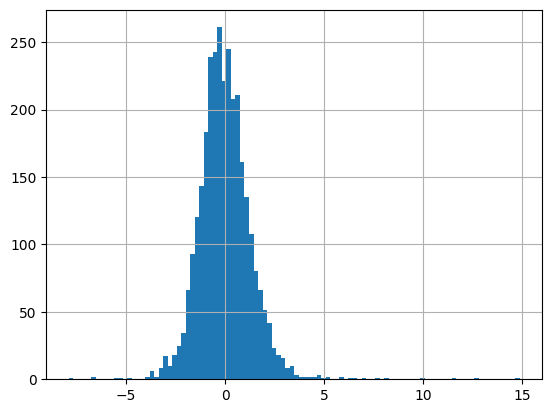

In [11]:
symbols['WOLF'].df['5DMA_slope'].hist(bins=100)

Close > Open by 5DMA Slope z-score

In [12]:
def close_above_open_probability_by_5dma_slope(df, max_std=3, forward_days=5):
    data = df[['Open', 'Close', '5DMA_slope']].replace([np.inf, -np.inf], np.nan).copy()
    valid_slopes = data['5DMA_slope'].dropna()

    slope_mean = valid_slopes.mean()
    slope_std = valid_slopes.std(ddof=1)
    if slope_std == 0 or np.isnan(slope_std):
        raise ValueError('5DMA_slope must have a non-zero standard deviation.')

    data['5DMA_slope_zscore'] = (data['5DMA_slope'] - slope_mean) / slope_std
    data = data.loc[data['5DMA_slope_zscore'].between(-max_std, max_std)].copy()

    outcome_columns = []
    for day in range(forward_days + 1):
        open_on_day = df['Open'].shift(-day)
        close_on_day = df['Close'].shift(-day)
        outcome_column = f'day_{day}'
        data[outcome_column] = (close_on_day > open_on_day).where(
            open_on_day.notna() & close_on_day.notna()
        )
        outcome_columns.append(outcome_column)

    bin_edges = np.arange(-max_std, max_std + 1, 1)
    bin_labels = [f'{left:+.0f}σ to {right:+.0f}σ' for left, right in zip(bin_edges[:-1], bin_edges[1:])]
    data['5DMA_slope_std_range'] = pd.cut(
        data['5DMA_slope_zscore'],
        bins=bin_edges,
        labels=bin_labels,
        include_lowest=True,
        right=True,
    )

    grouped = data.groupby('5DMA_slope_std_range', observed=False)[outcome_columns]
    probabilities = grouped.mean().mul(100).add_suffix('_probability_pct')
    observations = grouped.count().add_suffix('_observations')

    return pd.concat([probabilities, observations], axis=1)


close_above_open_probability_by_5dma_slope(symbols['SNDK'].df)

,day_0_probability_pct,day_1_probability_pct,day_2_probability_pct,day_3_probability_pct,day_4_probability_pct,day_5_probability_pct,day_0_observations,day_1_observations,day_2_observations,day_3_observations,day_4_observations,day_5_observations
5DMA_slope_std_range,,,,,,,,,,,,
-3σ to -2σ,41.538462,44.615385,50.769231,47.692308,44.615385,50.769231,65,65,65,65,65,65
-2σ to -1σ,43.734644,49.87715,49.140049,47.911548,44.471744,44.226044,407,407,407,407,407,407
-1σ to +0σ,47.652582,48.864526,49.373041,49.72549,50.549451,50.274941,1278,1277,1276,1275,1274,1273
+0σ to +1σ,50.921659,49.615975,49.615975,49.69278,50.460829,50.230415,1302,1302,1302,1302,1302,1302
+1σ to +2σ,56.351039,52.424942,51.732102,51.039261,48.960739,50.808314,433,433,433,433,433,433
+2σ to +3σ,63.013699,50.684932,47.945205,50.684932,54.794521,53.424658,73,73,73,73,73,73


Probability Close > Open by 5DMA Slope z-score given sMACD2050 > 0

In [13]:
def close_above_open_probability_given_positive_macd(df, max_std=3, forward_days=5):
    required_columns = ['Open', 'Close', '5DMA_slope', 'sMACD2050']
    data = df[required_columns].replace([np.inf, -np.inf], np.nan).copy()
    valid_slopes = data['5DMA_slope'].dropna()

    slope_mean = valid_slopes.mean()
    slope_std = valid_slopes.std(ddof=1)
    if slope_std == 0 or np.isnan(slope_std):
        raise ValueError('5DMA_slope must have a non-zero standard deviation.')

    data['5DMA_slope_zscore'] = (data['5DMA_slope'] - slope_mean) / slope_std
    data = data.loc[
        data['5DMA_slope_zscore'].between(-max_std, max_std)
        & data['sMACD2050'].gt(0)
    ].copy()

    outcome_columns = []
    for day in range(forward_days + 1):
        open_on_day = df['Open'].shift(-day)
        close_on_day = df['Close'].shift(-day)
        outcome_column = f'day_{day}'
        data[outcome_column] = (close_on_day > open_on_day).where(
            open_on_day.notna() & close_on_day.notna()
        )
        outcome_columns.append(outcome_column)

    bin_edges = np.arange(-max_std, max_std + 1, 1)
    bin_labels = [f'{left:+.0f}σ to {right:+.0f}σ' for left, right in zip(bin_edges[:-1], bin_edges[1:])]
    data['5DMA_slope_std_range'] = pd.cut(
        data['5DMA_slope_zscore'],
        bins=bin_edges,
        labels=bin_labels,
        include_lowest=True,
        right=True,
    )

    grouped = data.groupby('5DMA_slope_std_range', observed=False)[outcome_columns]
    probabilities = grouped.mean().mul(100).add_suffix('_probability_pct')
    observations = grouped.count().add_suffix('_observations')

    return pd.concat([probabilities, observations], axis=1)


close_above_open_probability_given_positive_macd(symbols['SNDK'].df)

,day_0_probability_pct,day_1_probability_pct,day_2_probability_pct,day_3_probability_pct,day_4_probability_pct,day_5_probability_pct,day_0_observations,day_1_observations,day_2_observations,day_3_observations,day_4_observations,day_5_observations
5DMA_slope_std_range,,,,,,,,,,,,
-3σ to -2σ,44.444444,27.777778,50.0,44.444444,38.888889,50.0,18,18,18,18,18,18
-2σ to -1σ,48.076923,58.974359,51.923077,46.153846,46.794872,43.589744,156,156,156,156,156,156
-1σ to +0σ,47.485207,49.481481,50.890208,50.965825,50.446429,50.372578,676,675,674,673,672,671
+0σ to +1σ,50.571792,47.776366,46.886912,49.047014,50.063532,50.063532,787,787,787,787,787,787
+1σ to +2σ,54.703833,52.61324,53.658537,51.916376,47.735192,50.174216,287,287,287,287,287,287
+2σ to +3σ,61.764706,50.0,45.588235,50.0,54.411765,54.411765,68,68,68,68,68,68


# Correlation

In [14]:
import pandas as pd
from market_data.price_data_import import intraday_import


STOCK = "SNDK"
LOOKBACK_DAYS = 200
INTRADAY_TIMEFRAME_MINUTES = 5
BENCHMARK = "SPY"

if LOOKBACK_DAYS < 1:
    raise ValueError("LOOKBACK_DAYS must be at least 1.")
if INTRADAY_TIMEFRAME_MINUTES < 1:
    raise ValueError("INTRADAY_TIMEFRAME_MINUTES must be at least 1.")

end_date = pd.Timestamp.now(tz="America/New_York").date()
start_date = (
    pd.Timestamp(end_date) - pd.Timedelta(days=LOOKBACK_DAYS - 1)
).date()

intraday_data = intraday_import(
    wl=[STOCK, BENCHMARK],
    from_date=start_date.isoformat(),
    to_date=end_date.isoformat(),
    timespan="minute",
    multiplier=INTRADAY_TIMEFRAME_MINUTES,
    market_open_only=True,
)

missing_symbols = {STOCK, BENCHMARK}.difference(intraday_data)
if missing_symbols:
    raise RuntimeError(
        f"No intraday data was returned for: {', '.join(sorted(missing_symbols))}"
    )

aligned_prices = pd.concat(
    {
        STOCK: intraday_data[STOCK]["Close"].pct_change(),
        BENCHMARK: intraday_data[BENCHMARK]["Close"].pct_change(),
    },
    axis=1,
    join="inner",
).dropna()

correlations_by_date = {}
for session_date, session_prices in aligned_prices.groupby(
    aligned_prices.index.normalize()
):
    correlations_by_date[session_date] = session_prices[STOCK].corr(
        session_prices[BENCHMARK]
    )

intraday_price_correlation = pd.Series(
    correlations_by_date,
    dtype="float64",
    name=f"{STOCK}_{BENCHMARK}_{INTRADAY_TIMEFRAME_MINUTES}min_price_correlation",
).sort_index()
intraday_price_correlation.index.name = "Date"

intraday_price_correlation

Importing Price Data: 100%|██████████| 2/2 [00:03<00:00,  1.71s/it]


Date
2026-03-23    0.507372
2026-03-24    0.455116
2026-03-25   -0.574756
2026-03-26    0.651211
2026-03-27    0.191467
                ...   
2026-10-02   -0.577853
2026-10-05    0.277250
2026-10-06   -0.182742
2026-10-07    0.555289
2026-10-08    0.690087
Name: SNDK_SPY_5min_price_correlation, Length: 139, dtype: float64

In [15]:
ABSOLUTE_CORRELATION_THRESHOLD = 0.90

if not 0 <= ABSOLUTE_CORRELATION_THRESHOLD <= 1:
    raise ValueError("ABSOLUTE_CORRELATION_THRESHOLD must be between 0 and 1.")

stock_daily_ohlc = intraday_data[STOCK].groupby(
    intraday_data[STOCK].index.normalize()
).agg(
    Open=("Open", "first"),
    Close=("Close", "last"),
)
stock_daily_ohlc.index.name = "Date"

correlation_and_price = pd.concat(
    [
        intraday_price_correlation.rename("Correlation"),
        stock_daily_ohlc,
    ],
    axis=1,
    join="inner",
).dropna()

qualifying_days = correlation_and_price.loc[
    correlation_and_price["Correlation"].abs()
    > ABSOLUTE_CORRELATION_THRESHOLD
].copy()
qualifying_days["Close_Above_Open"] = (
    qualifying_days["Close"] > qualifying_days["Open"]
)

correlation_condition_stats = pd.Series(
    {
        "Probability_Close_Above_Open": qualifying_days["Close_Above_Open"].mean(),
        "Observations": len(qualifying_days),
    },
    name=f"abs_correlation_gt_{ABSOLUTE_CORRELATION_THRESHOLD:.2f}",
)

correlation_condition_stats

Probability_Close_Above_Open    0.5
Observations                    2.0
Name: abs_correlation_gt_0.90, dtype: float64

# Time-Lagged Cross-Correlation

In [16]:
MAX_LAG_BARS = 6

if MAX_LAG_BARS < 0:
    raise ValueError("MAX_LAG_BARS must be nonnegative.")

aligned_closes = pd.concat(
    {
        STOCK: intraday_data[STOCK]["Close"],
        BENCHMARK: intraday_data[BENCHMARK]["Close"],
    },
    axis=1,
    join="inner",
).dropna()

daily_optimal_lags = []
for session_date, session_closes in aligned_closes.groupby(
    aligned_closes.index.normalize()
):
    # Calculate returns within each session so no overnight return is included.
    session_returns = session_closes.pct_change().dropna()
    lag_correlations = pd.Series(
        {
            lag: session_returns[STOCK].corr(
                session_returns[BENCHMARK].shift(lag)
            )
            for lag in range(-MAX_LAG_BARS, MAX_LAG_BARS + 1)
        },
        dtype="float64",
    ).dropna()

    if lag_correlations.empty:
        continue

    optimal_lag_bars = int(lag_correlations.abs().idxmax())
    daily_optimal_lags.append(
        {
            "Date": session_date,
            "Optimal_Lag_Bars": optimal_lag_bars,
            "Optimal_Lag_Minutes": (
                optimal_lag_bars * INTRADAY_TIMEFRAME_MINUTES
            ),
            "Optimal_Correlation": lag_correlations.loc[optimal_lag_bars],
        }
    )

daily_lagged_cross_correlation = (
    pd.DataFrame(daily_optimal_lags)
    .set_index("Date")
    .sort_index()
)
daily_lagged_cross_correlation.index.name = "Date"

# Positive lag: SPY leads the stock. Negative lag: the stock leads SPY.
daily_lagged_cross_correlation

,Optimal_Lag_Bars,Optimal_Lag_Minutes,Optimal_Correlation
Date,,,
2026-03-23,0,0,0.507372
2026-03-24,0,0,0.556839
2026-03-25,0,0,0.352947
2026-03-26,0,0,0.393457
2026-03-27,0,0,0.673780
...,...,...,...
2026-10-02,0,0,0.464208
2026-10-05,-3,-15,-0.310742
2026-10-06,4,20,-0.351339


In [17]:
ABSOLUTE_LAGGED_CORRELATION_THRESHOLD = 0.90

if not 0 <= ABSOLUTE_LAGGED_CORRELATION_THRESHOLD <= 1:
    raise ValueError(
        "ABSOLUTE_LAGGED_CORRELATION_THRESHOLD must be between 0 and 1."
    )

stock_daily_ohlc = intraday_data[STOCK].groupby(
    intraday_data[STOCK].index.normalize()
).agg(
    Open=("Open", "first"),
    Close=("Close", "last"),
)
stock_daily_ohlc.index.name = "Date"

lagged_correlation_and_price = daily_lagged_cross_correlation.join(
    stock_daily_ohlc,
    how="inner",
).dropna()

qualifying_lagged_days = lagged_correlation_and_price.loc[
    lagged_correlation_and_price["Optimal_Correlation"].abs()
    > ABSOLUTE_LAGGED_CORRELATION_THRESHOLD
].copy()
qualifying_lagged_days["Close_Above_Open"] = (
    qualifying_lagged_days["Close"] > qualifying_lagged_days["Open"]
)

lagged_correlation_condition_stats = pd.Series(
    {
        "Probability_Close_Above_Open": qualifying_lagged_days[
            "Close_Above_Open"
        ].mean(),
        "Observations": len(qualifying_lagged_days),
    },
    name=(
        "abs_optimal_lagged_correlation_gt_"
        f"{ABSOLUTE_LAGGED_CORRELATION_THRESHOLD:.2f}"
    ),
)

lagged_correlation_condition_stats

Probability_Close_Above_Open    NaN
Observations                    0.0
Name: abs_optimal_lagged_correlation_gt_0.90, dtype: float64

Machine Learning for Intraday Price Structure

Importing Price Data: 100%|██████████| 186/186 [02:04<00:00,  1.50it/s]
Clustered 5,332 complete high-beta sessions from 185 symbols | PCA components: 40 | Explained variance: 61.8%


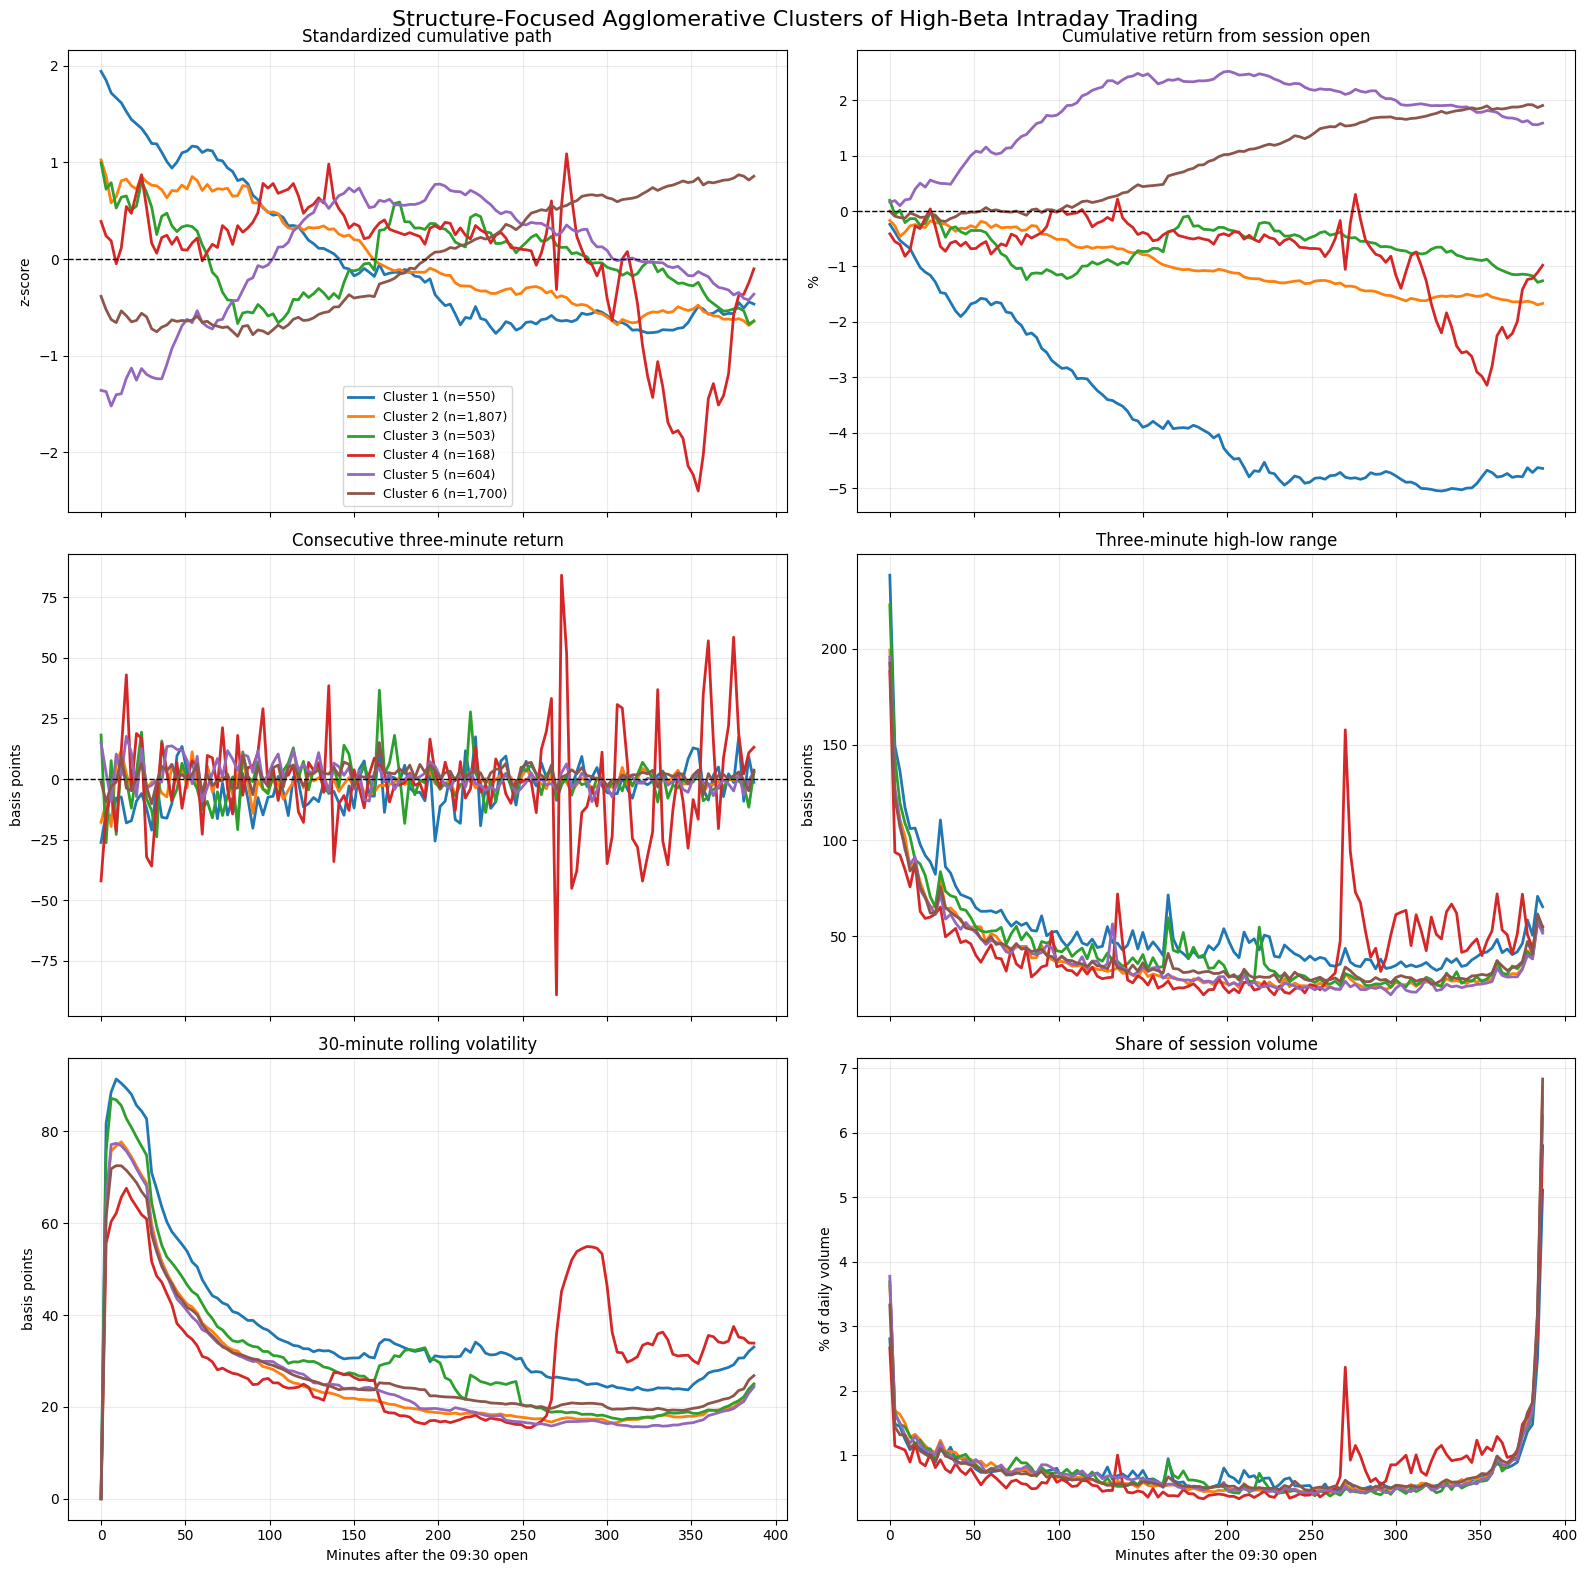

,sessions,unique_symbols,mean_session_return_pct,median_session_return_pct,mean_realized_volatility_pct,mean_maximum_drawdown_pct,median_minutes_to_high,median_minutes_to_low,percent_closing_lower
cluster,,,,,,,,,
1,550,176,-4.646053,-4.473506,5.020434,-7.345802,9.0,291.0,91.454545
2,1807,183,-1.668694,-1.616379,3.686017,-3.984375,27.0,264.0,75.816270
3,503,175,-1.259778,-1.366120,4.195035,-4.142632,24.0,105.0,68.389662
4,168,168,-0.978330,-1.205673,4.107533,-4.513497,94.5,354.0,64.880952
5,604,176,1.587503,1.212035,3.651280,-2.579840,153.0,12.0,30.132450
6,1700,184,1.905538,1.302215,3.815967,-2.832448,282.0,33.0,29.352941


,symbol,session_date,session_open,session_return,realized_volatility,maximum_drawdown,minutes_to_high,minutes_to_low,cluster,session_return_pct,realized_volatility_pct,maximum_drawdown_pct
0,INV,2026-10-07,0.5120,-0.475391,0.285004,-0.445041,0,387,1,-47.539062,28.500374,-44.504132
1,HQ,2026-09-14,14.6700,-0.294479,0.215179,-0.179600,6,333,1,-29.447853,21.517895,-17.960000
2,ARQQ,2026-10-08,22.1500,-0.166366,0.091157,-0.203724,0,348,1,-16.636569,9.115686,-20.372444
3,BRUN,2026-08-28,20.2000,-0.157426,0.057575,-0.192326,9,375,1,-15.742574,5.757475,-19.232625
4,TEM,2026-10-06,84.9650,-0.153063,0.065966,-0.185401,6,381,1,-15.306303,6.596560,-18.540063
...,...,...,...,...,...,...,...,...,...,...,...,...
5327,BBNX,2026-09-16,18.6100,0.193444,0.086079,-0.045933,387,0,6,19.344438,8.607931,-4.593301
5328,INV,2026-09-21,0.7314,0.203035,0.224854,-0.103835,369,15,6,20.303527,22.485382,-10.383488
5329,SHOE,2026-09-10,10.2000,0.203431,0.097927,-0.023685,297,0,6,20.343137,9.792720,-2.368527
5330,GEMI,2026-09-18,4.5700,0.270241,0.087668,-0.047198,387,3,6,27.024070,8.766819,-4.719764


In [18]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Combine both high-beta definitions used above. Limiting recent sessions per
# symbol keeps Ward clustering tractable while retaining broad symbol coverage.
HIGH_BETA_SYMBOLS = sorted(
    (set(finviz_high_beta) | set(price_betas.loc[price_betas > 3].dropna().index))
    - {BENCHMARK}
)
REGULAR_SESSION_MINUTES = 390
STRUCTURE_TIMEFRAME_MINUTES = 3
STRUCTURE_SESSIONS_PER_SYMBOL = 30
STRUCTURE_N_CLUSTERS = 6
STRUCTURE_PCA_COMPONENTS = 40
STRUCTURE_MAX_MISSING_BARS = 2

if STRUCTURE_TIMEFRAME_MINUTES < 1:
    raise ValueError("STRUCTURE_TIMEFRAME_MINUTES must be at least 1.")
if REGULAR_SESSION_MINUTES % STRUCTURE_TIMEFRAME_MINUTES:
    raise ValueError(
        "STRUCTURE_TIMEFRAME_MINUTES must divide evenly into the "
        f"{REGULAR_SESSION_MINUTES}-minute regular trading session."
    )
STRUCTURE_BARS_PER_SESSION = (
    REGULAR_SESSION_MINUTES // STRUCTURE_TIMEFRAME_MINUTES
)

if not HIGH_BETA_SYMBOLS:
    raise ValueError("The high-beta universe is empty.")

structure_start_date = (
    pd.Timestamp(end_date)
    - pd.Timedelta(days=max(LOOKBACK_DAYS - 1, 1))
).date()

high_beta_intraday_3min = intraday_import(
    wl=HIGH_BETA_SYMBOLS,
    from_date=structure_start_date.isoformat(),
    to_date=end_date.isoformat(),
    timespan="minute",
    multiplier=STRUCTURE_TIMEFRAME_MINUTES,
    market_open_only=True,
)

# Weight related feature families after standardization. Time remains aligned:
# feature 0 is always 09:30-09:32, feature 1 is 09:33-09:35, and so on.
STRUCTURE_FEATURE_WEIGHTS = {
    "standardized_path": 2.0,
    "consecutive_return": 2.0,
    "candle_body": 1.0,
    "intraday_range": 1.0,
    "drawdown": 1.0,
    "rolling_volatility": 1.0,
    "relative_volume": 0.75,
}

structure_feature_rows = {
    feature_name: [] for feature_name in STRUCTURE_FEATURE_WEIGHTS
}
structure_raw_paths = []
structure_metadata = []

for symbol, symbol_bars in high_beta_intraday_3min.items():
    if symbol_bars is None or symbol_bars.empty:
        continue

    symbol_bars = symbol_bars.sort_index()
    session_dates = pd.Index(symbol_bars.index.normalize().unique()).sort_values()
    session_dates = session_dates[-STRUCTURE_SESSIONS_PER_SYMBOL:]

    for session_date in session_dates:
        session = symbol_bars.loc[
            symbol_bars.index.normalize() == session_date,
            ["Open", "High", "Low", "Close", "Volume"],
        ].copy()
        if session.empty:
            continue

        minutes_after_midnight = session.index.hour * 60 + session.index.minute
        session["bar_number"] = (
            (minutes_after_midnight - (9 * 60 + 30))
            // STRUCTURE_TIMEFRAME_MINUTES
        )
        session = (
            session.loc[
                session["bar_number"].between(
                    0, STRUCTURE_BARS_PER_SESSION - 1
                )
            ]
            .drop_duplicates(subset="bar_number", keep="last")
            .set_index("bar_number")
            .reindex(range(STRUCTURE_BARS_PER_SESSION))
        )

        price_columns = ["Open", "High", "Low", "Close"]
        session[price_columns] = session[price_columns].interpolate(
            method="linear",
            limit=STRUCTURE_MAX_MISSING_BARS,
            limit_area="inside",
        )
        session["Volume"] = session["Volume"].interpolate(
            method="linear",
            limit=STRUCTURE_MAX_MISSING_BARS,
            limit_area="inside",
        )

        # Reject partial sessions, large gaps, invalid prices, and zero-volume days.
        if session.isna().any().any():
            continue
        if (session[price_columns] <= 0).any().any():
            continue
        if session["Volume"].sum() <= 0:
            continue

        first_open = float(session.iloc[0]["Open"])
        close = session["Close"].astype(float)
        open_ = session["Open"].astype(float)
        high = session["High"].astype(float)
        low = session["Low"].astype(float)
        volume = session["Volume"].clip(lower=0).astype(float)

        cumulative_path = close / first_open - 1
        path_scale = cumulative_path.std(ddof=0)
        if not np.isfinite(path_scale) or path_scale == 0:
            continue
        standardized_path = (
            cumulative_path - cumulative_path.mean()
        ) / path_scale

        previous_close = close.shift(1)
        previous_close.iloc[0] = open_.iloc[0]
        consecutive_return = np.log(close / previous_close)
        candle_body = close / open_ - 1
        intraday_range = (high - low) / previous_close
        drawdown = close / close.cummax() - 1
        rolling_volatility = consecutive_return.rolling(
            window=10, min_periods=2
        ).std(ddof=0).fillna(0)
        relative_volume = volume / volume.sum()

        feature_values = {
            "standardized_path": standardized_path.to_numpy(dtype=float),
            "consecutive_return": consecutive_return.to_numpy(dtype=float),
            "candle_body": candle_body.to_numpy(dtype=float),
            "intraday_range": intraday_range.to_numpy(dtype=float),
            "drawdown": drawdown.to_numpy(dtype=float),
            "rolling_volatility": rolling_volatility.to_numpy(dtype=float),
            "relative_volume": relative_volume.to_numpy(dtype=float),
        }
        if not all(np.isfinite(values).all() for values in feature_values.values()):
            continue

        for feature_name, values in feature_values.items():
            structure_feature_rows[feature_name].append(values)
        structure_raw_paths.append(cumulative_path.to_numpy(dtype=float))
        structure_metadata.append(
            {
                "symbol": symbol,
                "session_date": pd.Timestamp(session_date).normalize(),
                "session_open": first_open,
                "session_return": float(cumulative_path.iloc[-1]),
                "realized_volatility": float(
                    np.sqrt(np.square(consecutive_return).sum())
                ),
                "maximum_drawdown": float(drawdown.min()),
                "minutes_to_high": int(
                    close.to_numpy().argmax() * STRUCTURE_TIMEFRAME_MINUTES
                ),
                "minutes_to_low": int(
                    close.to_numpy().argmin() * STRUCTURE_TIMEFRAME_MINUTES
                ),
            }
        )

if len(structure_metadata) < STRUCTURE_N_CLUSTERS:
    raise ValueError(
        f"Only {len(structure_metadata)} complete high-beta sessions are "
        f"available for {STRUCTURE_N_CLUSTERS} clusters."
    )

# Scale each time-of-day feature across sessions, then apply family weights.
scaled_structure_blocks = []
structure_block_scalers = {}
for feature_name, weight in STRUCTURE_FEATURE_WEIGHTS.items():
    feature_matrix = np.vstack(structure_feature_rows[feature_name])
    scaler = StandardScaler()
    scaled_structure_blocks.append(
        scaler.fit_transform(feature_matrix) * weight
    )
    structure_block_scalers[feature_name] = scaler

structure_feature_matrix = np.hstack(scaled_structure_blocks)
structure_pca_components = min(
    STRUCTURE_PCA_COMPONENTS,
    structure_feature_matrix.shape[0] - 1,
    structure_feature_matrix.shape[1],
)
structure_pca = PCA(n_components=structure_pca_components)
structure_embedding = structure_pca.fit_transform(structure_feature_matrix)

structure_cluster_model = AgglomerativeClustering(
    n_clusters=STRUCTURE_N_CLUSTERS,
    linkage="ward",
)
raw_structure_labels = structure_cluster_model.fit_predict(structure_embedding)
structure_raw_paths_matrix = np.vstack(structure_raw_paths)

# Renumber arbitrary model labels by mean closing return for easier comparison.
raw_label_final_returns = {
    label: structure_raw_paths_matrix[raw_structure_labels == label, -1].mean()
    for label in np.unique(raw_structure_labels)
}
ordered_structure_labels = sorted(
    raw_label_final_returns, key=raw_label_final_returns.get
)
structure_label_map = {
    original_label: cluster_number
    for cluster_number, original_label in enumerate(
        ordered_structure_labels, start=1
    )
}
structure_labels = np.array(
    [structure_label_map[label] for label in raw_structure_labels]
)

structure_cluster_assignments = pd.DataFrame(structure_metadata)
structure_cluster_assignments["cluster"] = structure_labels
for column in ["session_return", "realized_volatility", "maximum_drawdown"]:
    structure_cluster_assignments[f"{column}_pct"] = (
        structure_cluster_assignments[column] * 100
    )

structure_cluster_summary = (
    structure_cluster_assignments.groupby("cluster")
    .agg(
        sessions=("symbol", "size"),
        unique_symbols=("symbol", "nunique"),
        mean_session_return_pct=("session_return_pct", "mean"),
        median_session_return_pct=("session_return_pct", "median"),
        mean_realized_volatility_pct=("realized_volatility_pct", "mean"),
        mean_maximum_drawdown_pct=("maximum_drawdown_pct", "mean"),
        median_minutes_to_high=("minutes_to_high", "median"),
        median_minutes_to_low=("minutes_to_low", "median"),
        percent_closing_lower=(
            "session_return", lambda returns: returns.lt(0).mean() * 100
        ),
    )
    .sort_index()
)

structure_explained_variance = structure_pca.explained_variance_ratio_.sum()
print(
    f"Clustered {len(structure_cluster_assignments):,} complete high-beta sessions "
    f"from {structure_cluster_assignments['symbol'].nunique():,} symbols | "
    f"PCA components: {structure_pca_components} | "
    f"Explained variance: {structure_explained_variance:.1%}"
)

# Plot raw quantities for interpretation even though clustering used scaled,
# weighted, and PCA-denoised features.
minutes = np.arange(STRUCTURE_BARS_PER_SESSION) * STRUCTURE_TIMEFRAME_MINUTES
raw_feature_matrices = {
    name: np.vstack(rows) for name, rows in structure_feature_rows.items()
}
fig, axes = plt.subplots(3, 2, figsize=(16, 16), sharex=True)
plot_specs = [
    ("standardized_path", "Standardized cumulative path", "z-score"),
    ("raw_path", "Cumulative return from session open", "%"),
    ("consecutive_return", "Consecutive three-minute return", "basis points"),
    ("intraday_range", "Three-minute high-low range", "basis points"),
    ("rolling_volatility", "30-minute rolling volatility", "basis points"),
    ("relative_volume", "Share of session volume", "% of daily volume"),
]

for ax, (feature_name, title, ylabel) in zip(axes.flat, plot_specs):
    matrix = (
        structure_raw_paths_matrix
        if feature_name == "raw_path"
        else raw_feature_matrices[feature_name]
    )
    multiplier = 1
    if feature_name in {"raw_path", "relative_volume"}:
        multiplier = 100
    elif feature_name in {
        "consecutive_return", "intraday_range", "rolling_volatility"
    }:
        multiplier = 10_000

    for cluster_number in range(1, STRUCTURE_N_CLUSTERS + 1):
        cluster_values = matrix[structure_labels == cluster_number] * multiplier
        ax.plot(
            minutes,
            cluster_values.mean(axis=0),
            linewidth=2,
            label=f"Cluster {cluster_number} (n={len(cluster_values):,})",
        )

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    if feature_name in {"standardized_path", "raw_path", "consecutive_return"}:
        ax.axhline(0, color="black", linewidth=1, linestyle="--")

for ax in axes[-1, :]:
    ax.set_xlabel("Minutes after the 09:30 open")
axes[0, 0].legend(fontsize=9)
fig.suptitle(
    "Structure-Focused Agglomerative Clusters of High-Beta Intraday Trading",
    fontsize=16,
)
plt.tight_layout()
plt.show()

display(structure_cluster_summary)
display(
    structure_cluster_assignments.sort_values(
        ["cluster", "session_return"], ascending=[True, True]
    ).reset_index(drop=True)
)

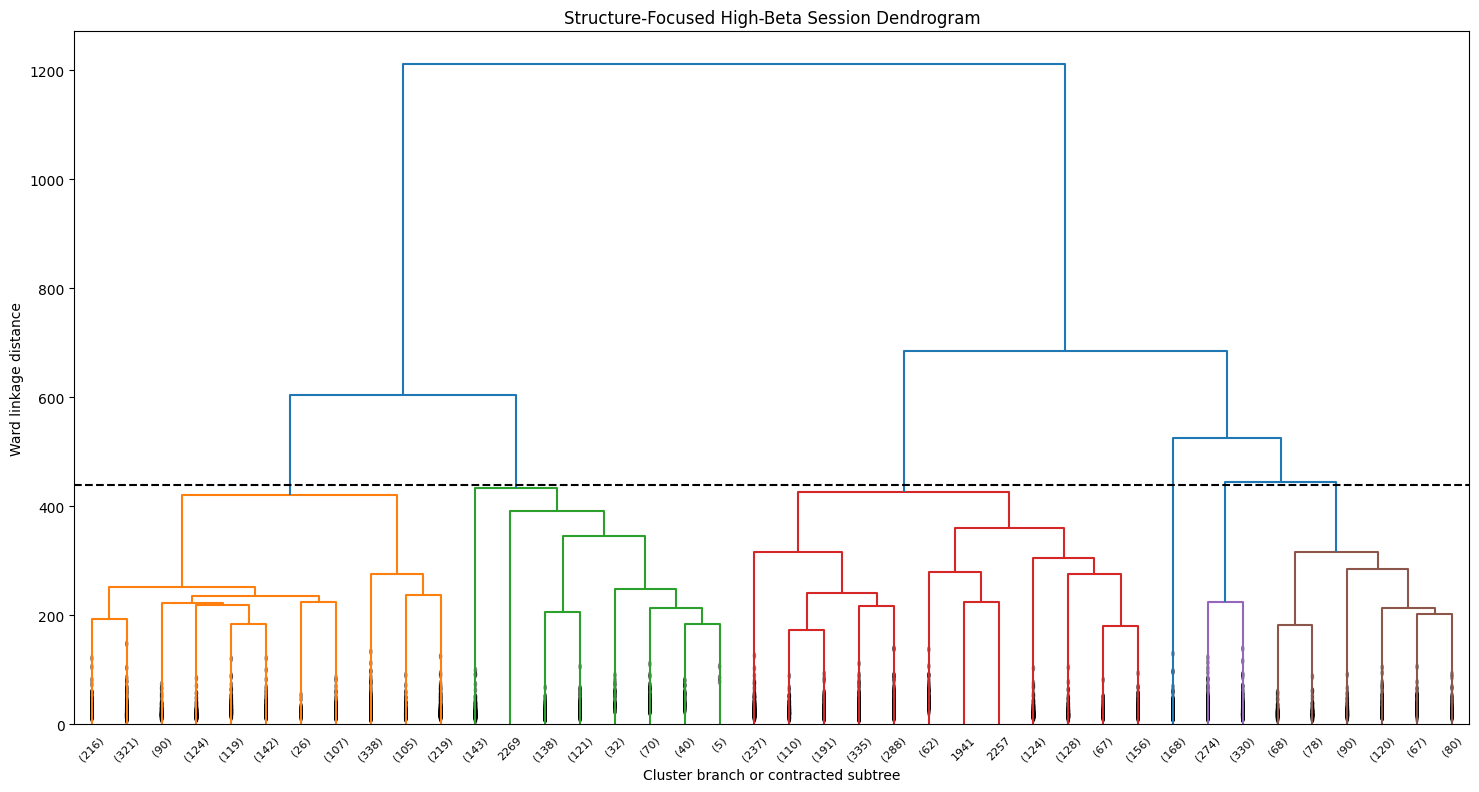

In [19]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

structure_linkage = linkage(
    structure_embedding,
    method="ward",
    metric="euclidean",
)

# Threshold corresponding approximately to the configured number of clusters.
cut_threshold = (
    structure_linkage[-STRUCTURE_N_CLUSTERS, 2]
    + structure_linkage[-(STRUCTURE_N_CLUSTERS - 1), 2]
) / 2

plt.figure(figsize=(18, 9))
dendrogram(
    structure_linkage,
    truncate_mode="lastp",
    p=40,
    show_contracted=True,
    color_threshold=cut_threshold,
)
plt.axhline(cut_threshold, color="black", linestyle="--")
plt.title("Structure-Focused High-Beta Session Dendrogram")
plt.xlabel("Cluster branch or contracted subtree")
plt.ylabel("Ward linkage distance")
plt.show()

In [20]:
from scipy.cluster.hierarchy import dendrogram, to_tree

# Map each displayed dendrogram leaf (including contracted subtrees) back to
# the underlying high-beta trading sessions.
dendrogram_result = dendrogram(
    structure_linkage,
    truncate_mode="lastp",
    p=40,
    show_contracted=True,
    color_threshold=cut_threshold,
    no_plot=True,
)

_, linkage_nodes = to_tree(structure_linkage, rd=True)
contracted_subtree_members = {}
subtree_summary = []

for position, node_id in enumerate(dendrogram_result["leaves"]):
    observation_indices = linkage_nodes[node_id].pre_order(
        lambda leaf: leaf.id
    )
    members = structure_cluster_assignments.iloc[observation_indices].copy()
    members["observation_index"] = observation_indices
    contracted_subtree_members[position] = members

    subtree_summary.append(
        {
            "x_position": position,
            "display_label": dendrogram_result["ivl"][position],
            "linkage_node": node_id,
            "observations": len(members),
            "unique_symbols": members["symbol"].nunique(),
            "first_session": members["session_date"].min(),
            "last_session": members["session_date"].max(),
        }
    )

subtree_summary = pd.DataFrame(subtree_summary)
display(subtree_summary)

,x_position,display_label,linkage_node,observations,unique_symbols,first_session,last_session
0,0,(216),10606,216,125,2026-08-27,2026-10-08
1,1,(321),10621,321,150,2026-08-27,2026-10-08
2,2,(90),10559,90,89,2026-09-10,2026-09-23
3,3,(124),10575,124,121,2026-09-10,2026-10-06
4,4,(119),10599,119,84,2026-08-27,2026-10-08
5,5,(142),10620,142,106,2026-08-28,2026-10-07
6,6,(26),10566,26,26,2026-09-15,2026-09-15
7,7,(107),10589,107,104,2026-08-27,2026-09-18
8,8,(338),10619,338,152,2026-08-27,2026-10-07
9,9,(105),10558,105,104,2026-09-17,2026-09-29


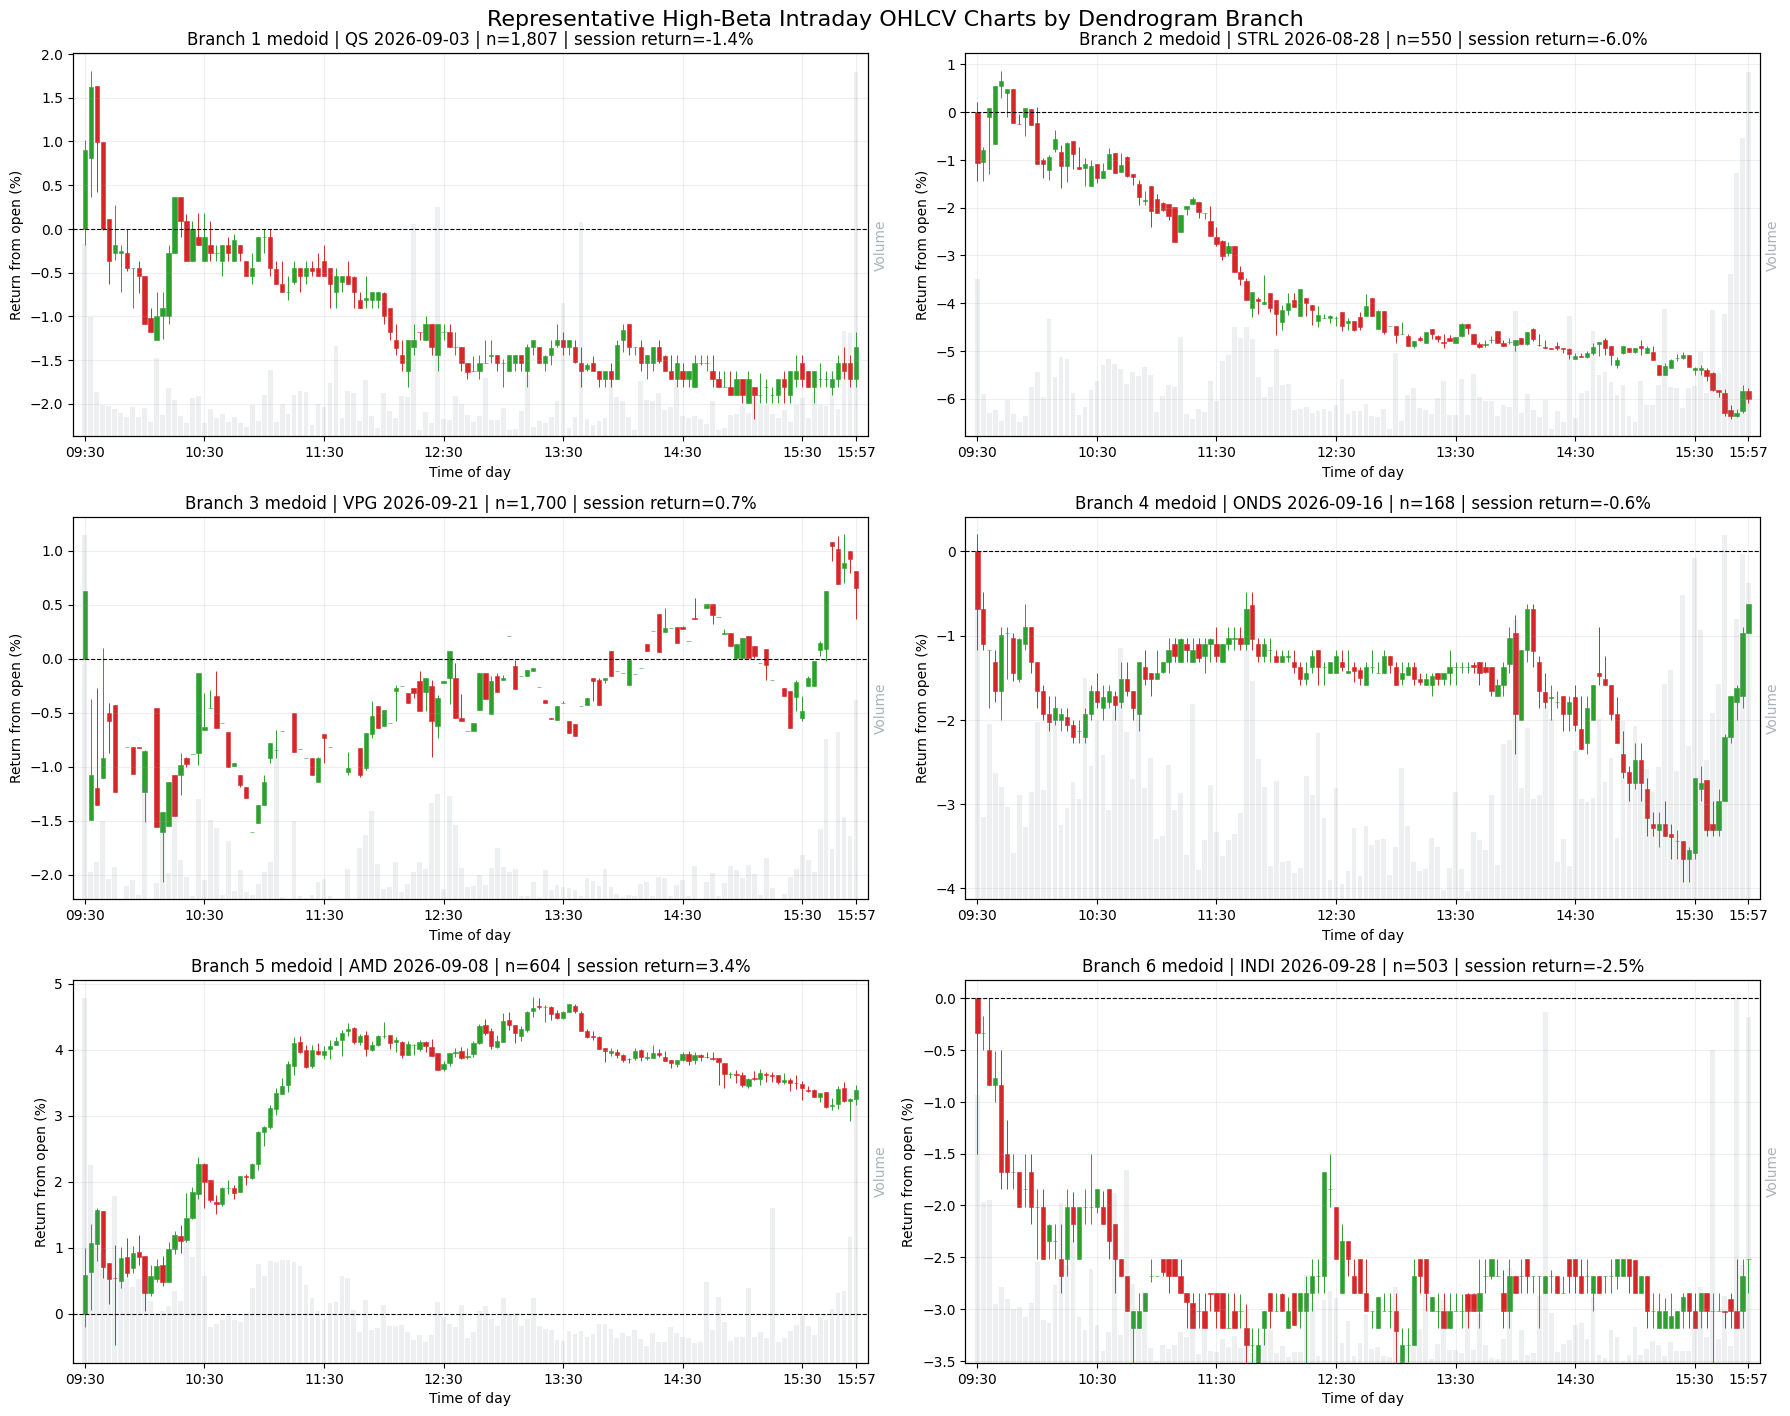

Dendrogram cut at 439.407 produced 6 branches.


,dendrogram_cluster,representative_rank,is_medoid,cluster_size,symbol,session_date,session_return_pct,realized_volatility_pct,maximum_drawdown_pct,distance_from_medoid
0,1,1,True,1807,QS,2026-09-03,-1.356239,2.631022,-3.469751,0.000000
1,1,2,False,1807,LTBR,2026-09-03,-2.604167,2.855165,-3.813833,14.349660
2,1,3,False,1807,HOOD,2026-10-06,-2.608469,2.435776,-3.668191,14.500999
3,2,1,True,550,STRL,2026-08-28,-6.011748,3.118838,-6.960587,0.000000
4,2,2,False,550,ONTO,2026-08-28,-6.562813,2.947448,-6.659536,10.978773
5,2,3,False,550,CLS,2026-08-28,-5.057143,2.472057,-5.302639,12.387400
6,3,1,True,1700,VPG,2026-09-21,0.657946,3.242559,-2.215385,0.000000
7,3,2,False,1700,BHVN,2026-09-04,1.159794,3.512466,-1.985906,15.494402
8,3,3,False,1700,VELO,2026-09-22,2.127660,3.263020,-2.743363,15.920850
9,4,1,True,168,ONDS,2026-09-16,-0.619408,3.209752,-2.979903,0.000000


Saved 6 branch medoids to E:\Market Research\Dataset\market_data_pickled\high_beta_medoid_library.pkl


In [21]:
from scipy.cluster.hierarchy import fcluster
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

REPRESENTATIVES_PER_CLUSTER = 3

# Use the same horizontal boundary displayed on the dendrogram. Each resulting
# label therefore corresponds to one branch below the dashed cut line.
dendrogram_labels = fcluster(
    structure_linkage,
    t=cut_threshold,
    criterion="distance",
)
dendrogram_cluster_count = int(np.unique(dendrogram_labels).size)

if len(dendrogram_labels) != len(structure_cluster_assignments):
    raise ValueError(
        "The linkage observations and structure-cluster metadata are not aligned."
    )

dendrogram_cluster_assignments = (
    structure_cluster_assignments.copy().reset_index(drop=True)
)
dendrogram_cluster_assignments["dendrogram_cluster"] = dendrogram_labels

# A medoid is an actual session that minimizes its average distance to all
# other members of its dendrogram branch. Additional representatives are the
# observations nearest to that medoid.
representative_rows = []
for cluster_number in sorted(np.unique(dendrogram_labels)):
    cluster_indices = np.flatnonzero(dendrogram_labels == cluster_number)
    cluster_embedding = structure_embedding[cluster_indices]
    within_cluster_distances = cdist(
        cluster_embedding,
        cluster_embedding,
        metric="euclidean",
    )
    medoid_local_index = int(
        within_cluster_distances.mean(axis=1).argmin()
    )
    distance_from_medoid = within_cluster_distances[medoid_local_index]
    nearest_local_indices = np.argsort(distance_from_medoid)[
        : min(REPRESENTATIVES_PER_CLUSTER, len(cluster_indices))
    ]

    for representative_rank, local_index in enumerate(
        nearest_local_indices, start=1
    ):
        observation_index = int(cluster_indices[local_index])
        observation = dendrogram_cluster_assignments.iloc[observation_index]
        representative_rows.append(
            {
                "dendrogram_cluster": int(cluster_number),
                "representative_rank": representative_rank,
                "is_medoid": representative_rank == 1,
                "cluster_size": len(cluster_indices),
                "symbol": observation["symbol"],
                "session_date": observation["session_date"],
                "session_return_pct": observation["session_return_pct"],
                "realized_volatility_pct": observation[
                    "realized_volatility_pct"
                ],
                "maximum_drawdown_pct": observation[
                    "maximum_drawdown_pct"
                ],
                "distance_from_medoid": float(
                    distance_from_medoid[local_index]
                ),
                "observation_index": observation_index,
            }
        )

representative_session_charts = pd.DataFrame(representative_rows)
dendrogram_cluster_medoids = representative_session_charts.loc[
    representative_session_charts["is_medoid"]
].copy()


def _plot_representative_session(ax, representative):
    symbol = representative["symbol"]
    session_date = pd.Timestamp(representative["session_date"]).normalize()
    symbol_bars = high_beta_intraday_3min.get(symbol)
    if symbol_bars is None or symbol_bars.empty:
        ax.set_visible(False)
        return

    session = symbol_bars.loc[
        symbol_bars.index.normalize() == session_date,
        ["Open", "High", "Low", "Close", "Volume"],
    ].copy()
    session = session.apply(pd.to_numeric, errors="coerce").dropna()
    if session.empty:
        ax.set_visible(False)
        return

    minutes_after_midnight = session.index.hour * 60 + session.index.minute
    x = np.asarray(
        (minutes_after_midnight - (9 * 60 + 30))
        / STRUCTURE_TIMEFRAME_MINUTES,
        dtype=float,
    )
    first_open = float(session.iloc[0]["Open"])
    open_return = (session["Open"].to_numpy() / first_open - 1) * 100
    high_return = (session["High"].to_numpy() / first_open - 1) * 100
    low_return = (session["Low"].to_numpy() / first_open - 1) * 100
    close_return = (session["Close"].to_numpy() / first_open - 1) * 100
    up_bar = close_return >= open_return
    colors = np.where(up_bar, "#2ca02c", "#d62728")

    ax.vlines(x, low_return, high_return, color=colors, linewidth=0.7)
    ax.bar(
        x,
        np.abs(close_return - open_return),
        bottom=np.minimum(open_return, close_return),
        width=0.72,
        color=colors,
        edgecolor=colors,
        linewidth=0.4,
    )
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.grid(alpha=0.2)
    ax.set_xlim(-2, STRUCTURE_BARS_PER_SESSION + 1)
    ax.set_ylabel("Return from open (%)")
    ax.set_title(
        f"Branch {int(representative['dendrogram_cluster'])} medoid | "
        f"{symbol} {session_date:%Y-%m-%d} | "
        f"n={int(representative['cluster_size']):,} | "
        f"session return={representative['session_return_pct']:.1f}%"
    )

    volume_axis = ax.twinx()
    volume_axis.bar(
        x,
        session["Volume"].to_numpy(),
        width=0.8,
        color="slategray",
        alpha=0.12,
    )
    volume_axis.set_yticks([])
    volume_axis.set_ylabel("Volume", color="slategray", alpha=0.6)

    tick_positions = np.array([0, 20, 40, 60, 80, 100, 120, 129])
    tick_minutes = (
        9 * 60 + 30 + tick_positions * STRUCTURE_TIMEFRAME_MINUTES
    )
    tick_labels = [
        f"{minute // 60:02d}:{minute % 60:02d}" for minute in tick_minutes
    ]
    ax.set_xticks(tick_positions, tick_labels)
    ax.set_xlabel("Time of day")


figure_rows = int(np.ceil(dendrogram_cluster_count / 2))
fig, axes = plt.subplots(
    figure_rows,
    2,
    figsize=(18, 4.8 * figure_rows),
    squeeze=False,
)
for ax, (_, medoid) in zip(axes.flat, dendrogram_cluster_medoids.iterrows()):
    _plot_representative_session(ax, medoid)
for ax in axes.flat[len(dendrogram_cluster_medoids):]:
    ax.set_visible(False)

fig.suptitle(
    "Representative High-Beta Intraday OHLCV Charts by Dendrogram Branch",
    fontsize=16,
)
plt.tight_layout()
plt.show()

print(
    f"Dendrogram cut at {cut_threshold:.3f} produced "
    f"{dendrogram_cluster_count} branches."
)
display(
    representative_session_charts.drop(columns="observation_index").sort_values(
        ["dendrogram_cluster", "representative_rank"]
    )
)

# Persist the actual medoid return paths and metadata for live prefix matching.
import pickle
from pathlib import Path

MEDOID_ARTIFACT_PATH = Path(
    r"E:\Market Research\Dataset\market_data_pickled\high_beta_medoid_library.pkl"
)
medoid_library = {}
for medoid in dendrogram_cluster_medoids.itertuples(index=False):
    observation_index = int(medoid.observation_index)
    branch = int(medoid.dendrogram_cluster)
    medoid_library[branch] = {
        "branch": branch,
        "symbol": str(medoid.symbol),
        "session_date": pd.Timestamp(medoid.session_date).date().isoformat(),
        "observation_index": observation_index,
        "session_return_pct": float(medoid.session_return_pct),
        "cumulative_return_path": structure_raw_paths_matrix[
            observation_index
        ].copy(),
    }

medoid_artifact = {
    "artifact_version": 1,
    "created_at": pd.Timestamp.now(tz="America/New_York").isoformat(),
    "timeframe_minutes": int(STRUCTURE_TIMEFRAME_MINUTES),
    "regular_session_minutes": int(REGULAR_SESSION_MINUTES),
    "bars_per_session": int(STRUCTURE_BARS_PER_SESSION),
    "high_beta_symbols": list(HIGH_BETA_SYMBOLS),
    "medoids": medoid_library,
}
MEDOID_ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)
with MEDOID_ARTIFACT_PATH.open("wb") as artifact_file:
    pickle.dump(medoid_artifact, artifact_file, protocol=pickle.HIGHEST_PROTOCOL)

print(
    f"Saved {len(medoid_library)} branch medoids to "
    f"{MEDOID_ARTIFACT_PATH}"
)

- Medoid Studies

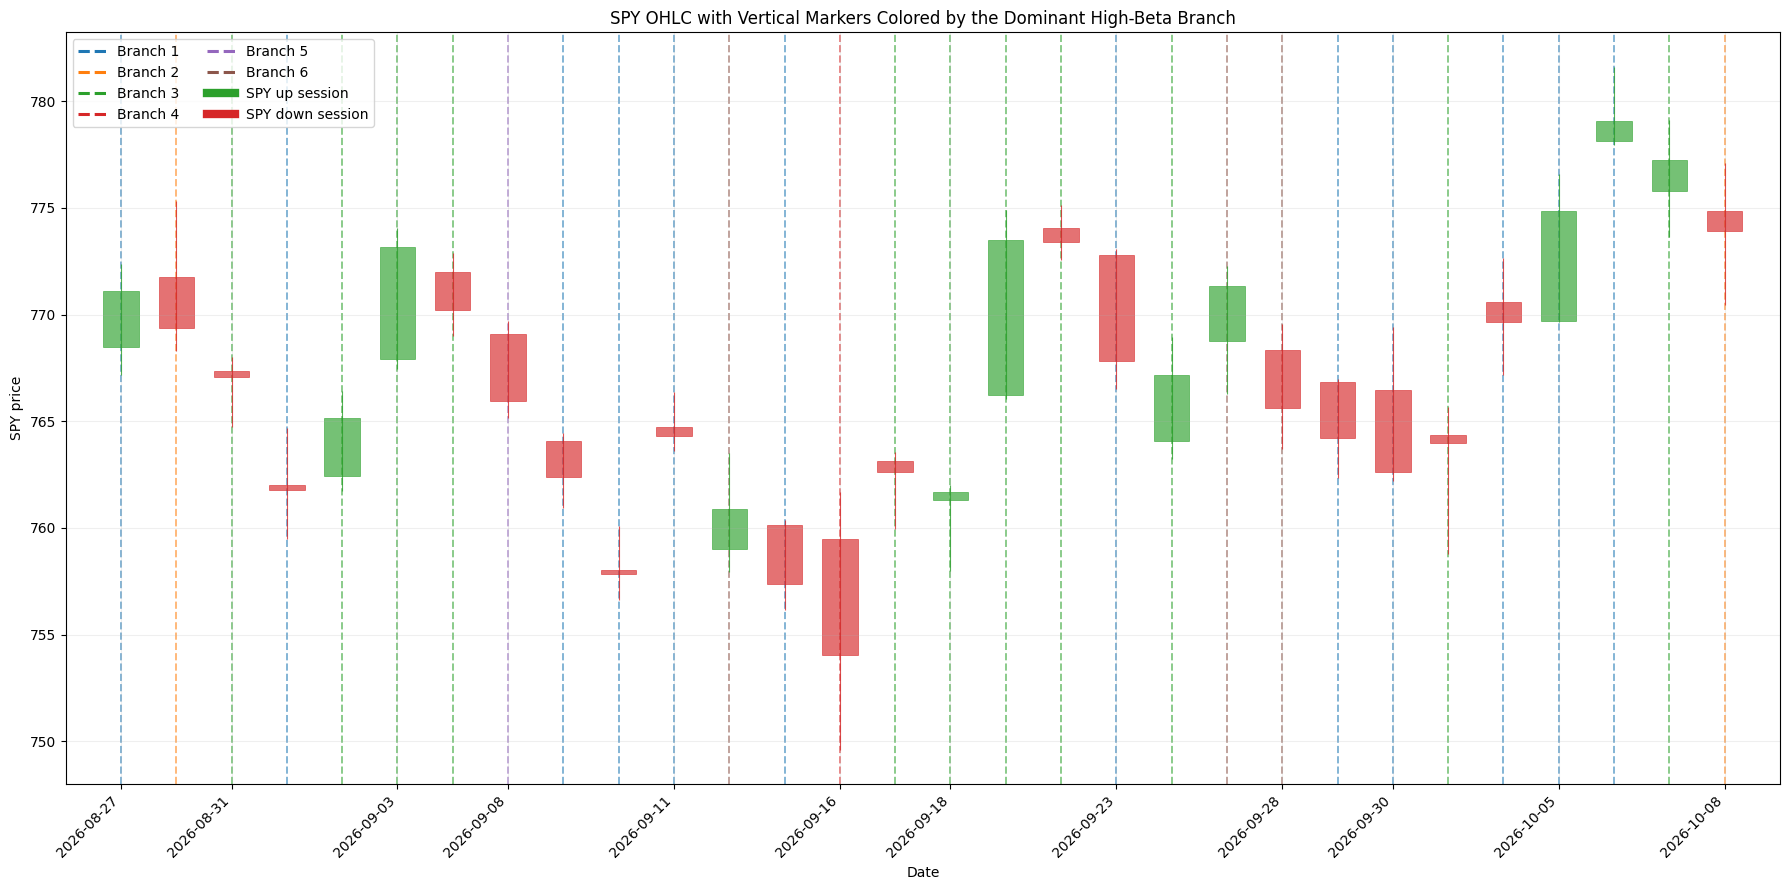

,branch_1,branch_1_count,branch_2,branch_2_count,branch_3,branch_3_count,branch_4,branch_4_count,branch_5,branch_5_count,branch_6,branch_6_count
Date,,,,,,,,,,,,
2026-08-27,"(AAOI, ABTC, ACHR, AEHR, AEVA, AFRM, AGNT, ALA...",79,"(BTBT, EVTL, GPUS, HQ, SLNH, TSSI)",6,"(ABSI, ALM, ASM, ASTS, BAND, BFLY, BHVN, BRUN,...",34,NaN,0,"(ABAT, ACMR, AIP, AMBQ, ARQQ, ASPI, BBAI, BE, ...",55,"(P, PURR, RUM)",3
2026-08-28,"(AGNT, ALAB, AMD, BBNX, BFLY, COHR, CRDO, CVNA...",21,"(AAOI, ABAT, ABSI, ABTC, ACHR, ACMR, AEHR, AEV...",150,"(INBX, SERV, SYRE)",3,NaN,0,"(PONY, STUB)",2,NaN,0
2026-08-31,"(ACMR, AEHR, AGNT, AIP, AMKR, AMSC, AXTI, BAND...",62,"(BTQ, GPUS, LPTH)",3,"(AAOI, ABAT, ABSI, ABTC, ACHR, AEVA, AFRM, ALA...",89,NaN,0,"(IONQ, JOBY, PGY, QUBT, RR, SEZL, SGMT, SIDU, ...",11,"(EOSE, FLY, MDA, NB, OKLO, QBTS, RCAT, RGTI, S...",12
2026-09-01,"(ABAT, ABSI, ABTC, ACMR, AEHR, AEVA, AFRM, AGN...",134,"(BTBT, DAVE, DPRO, EVTL, GPUS, IE, INV, NTSK, XE)",9,"(AAOI, ACHR, AMBQ, AMSC, ASPI, BAND, BE, BHVN,...",28,NaN,0,"(CVNA, QBTS, QS, RGTI, RXT, SNDK, TSSI)",7,NaN,0
2026-09-02,"(AAOI, ACMR, AEVA, AGNT, ALAB, ALMU, AMD, AMPX...",50,"(ABSI, AEHR, AXTI, BAND, BFLY, BHVN, BRUN, CRD...",14,"(ABAT, ABTC, ACHR, AIP, ALM, AMBQ, AMKR, AMSC,...",108,NaN,0,"(AFRM, CVNA, INDI, OPEN, SMTC, SPCX, TER)",7,NaN,0
2026-09-03,"(ABAT, ACHR, AEHR, AEVA, ALM, ALMU, ARQQ, ASPI...",52,"(BKSY, BTQ, EVTL, GPUS, HQ, NTSK, RR, SATL, SIDU)",9,"(ABTC, AFRM, AGNT, APLD, ARM, ASM, ASST, BBNX,...",73,NaN,0,"(AAOI, ABSI, ACMR, AIP, ALAB, AMBQ, AMD, AMKR,...",43,"(INV,)",1
2026-09-04,"(AAOI, ABSI, ALAB, APLD, ARM, ASM, ASTS, BAND,...",44,"(ABTC, DPRO, GPUS, INV, NTSK, USAR, XNDU)",7,"(ACHR, ACMR, AEHR, AEVA, AFRM, ALMU, AMD, AMPX...",75,NaN,0,"(ABAT, AGNT, BKKT, BMNR, CLSK, COIN, FLNC, FLY...",32,"(AIP, ALM, AMKR, AOSL, CRML, FCEL, LRCX, MRAM,...",15
2026-09-08,"(ABAT, AEHR, ALAB, ALMU, ASM, ASPI, BHVN, BTQ,...",41,"(GPUS, INBX, STUB, XE)",4,"(AFRM, AGNT, ALM, AOSL, BAND, BFLY, BTBT, CVNA...",22,NaN,0,"(AAOI, ABSI, ABTC, ACHR, ACMR, AEVA, AIP, AMBQ...",109,"(BBNX, POET)",2
2026-09-09,"(AAOI, ABAT, ACHR, ACMR, AEHR, AFRM, AGNT, AIP...",81,"(ABTC, AEVA, ASPI, ASST, BRUN, BTBT, CIFR, CRM...",27,"(ABSI, AMBQ, AMD, BAND, BHVN, BTQ, DDD, ENTG, ...",22,NaN,0,"(ASM, INOD, NTSK, SCZM, SYRE)",5,"(ALM, AMKR, AMPX, ASTS, BKSY, CEVA, CVNA, EVTL...",41


In [22]:
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

# Each cell contains the symbols assigned to that dendrogram branch on that date.
branch_symbols_by_date = (
    dendrogram_cluster_assignments
    .groupby(["session_date", "dendrogram_cluster"])["symbol"]
    .agg(lambda values: tuple(sorted(set(values))))
    .unstack("dendrogram_cluster")
    .sort_index()
)
branch_symbols_by_date.columns = [
    f"branch_{int(branch)}" for branch in branch_symbols_by_date.columns
]
branch_symbols_by_date.index.name = "Date"

# Determine which branch contains the most unique symbols on each date. Ties
# resolve to the lowest-numbered branch because DataFrame.idxmax returns the
# first maximum.
branch_counts_by_date = (
    dendrogram_cluster_assignments
    .groupby(["session_date", "dendrogram_cluster"])["symbol"]
    .nunique()
    .unstack("dendrogram_cluster", fill_value=0)
    .sort_index()
)

# Add each branch's symbol count beside its tuple of symbols.
branch_output_columns = []
for branch in branch_counts_by_date.columns:
    symbol_column = f"branch_{int(branch)}"
    count_column = f"{symbol_column}_count"
    branch_symbols_by_date[count_column] = branch_counts_by_date[branch].astype(int)
    branch_output_columns.extend([symbol_column, count_column])
branch_symbols_by_date = branch_symbols_by_date[branch_output_columns]

dominant_branch_by_date = (
    branch_counts_by_date.idxmax(axis=1).astype(int).rename("dominant_branch")
)
dominant_branch_symbol_count = (
    branch_counts_by_date.max(axis=1).astype(int).rename("dominant_symbol_count")
)

# Align the daily SPY OHLC data to the dates represented in the clustering.
spy_ohlc = etfs["SPY"].df[["Open", "High", "Low", "Close"]].copy()
spy_ohlc.index = pd.to_datetime(spy_ohlc.index).normalize()
spy_ohlc.index.name = "Date"
spy_medoid_plot_data = (
    spy_ohlc
    .join(dominant_branch_by_date, how="inner")
    .join(dominant_branch_symbol_count, how="left")
    .dropna(subset=["Open", "High", "Low", "Close", "dominant_branch"])
    .sort_index()
)

if spy_medoid_plot_data.empty:
    raise ValueError("No SPY dates overlap the clustered high-beta sessions.")

branch_numbers = sorted(branch_counts_by_date.columns.astype(int))
color_map = plt.get_cmap("tab10")
branch_colors = {
    branch: color_map(index % color_map.N)
    for index, branch in enumerate(branch_numbers)
}

fig, ax = plt.subplots(figsize=(18, 9))
x = np.arange(len(spy_medoid_plot_data), dtype=float)
opens = spy_medoid_plot_data["Open"].to_numpy(dtype=float)
highs = spy_medoid_plot_data["High"].to_numpy(dtype=float)
lows = spy_medoid_plot_data["Low"].to_numpy(dtype=float)
closes = spy_medoid_plot_data["Close"].to_numpy(dtype=float)

# Draw SPY OHLC candles without requiring an additional plotting dependency.
up_sessions = closes >= opens
candle_colors = np.where(up_sessions, "#2ca02c", "#d62728")
ax.vlines(x, lows, highs, color=candle_colors, linewidth=0.8, alpha=0.8)
for position, open_price, close_price, color in zip(
    x, opens, closes, candle_colors
):
    body_low = min(open_price, close_price)
    body_height = abs(close_price - open_price)
    if body_height == 0:
        ax.hlines(open_price, position - 0.32, position + 0.32, color=color)
    else:
        ax.add_patch(
            Rectangle(
                (position - 0.32, body_low),
                0.64,
                body_height,
                facecolor=color,
                edgecolor=color,
                linewidth=0.6,
                alpha=0.65,
            )
        )

# Draw one vertical dashed marker per date. Its color identifies the branch
# containing the largest number of high-beta symbols on that date.
for position, branch in zip(
    x, spy_medoid_plot_data["dominant_branch"].astype(int)
):
    ax.axvline(
        position,
        color=branch_colors[branch],
        linewidth=1.4,
        linestyle="--",
        alpha=0.55,
        zorder=0,
    )

number_of_ticks = min(12, len(spy_medoid_plot_data))
tick_positions = np.unique(
    np.linspace(0, len(spy_medoid_plot_data) - 1, number_of_ticks).astype(int)
)
ax.set_xticks(tick_positions)
ax.set_xticklabels(
    spy_medoid_plot_data.index[tick_positions].strftime("%Y-%m-%d"),
    rotation=45,
    ha="right",
)
ax.set_xlim(-1, len(spy_medoid_plot_data))
ax.set_ylabel("SPY price")
ax.set_xlabel("Date")
ax.set_title(
    "SPY OHLC with Vertical Markers Colored by the Dominant High-Beta Branch"
)
ax.grid(alpha=0.2)

legend_handles = [
    Line2D(
        [0],
        [0],
        color=branch_colors[branch],
        linestyle="--",
        linewidth=2.2,
        label=f"Branch {branch}",
    )
    for branch in branch_numbers
]
legend_handles.extend(
    [
        Line2D([0], [0], color="#2ca02c", linewidth=6, label="SPY up session"),
        Line2D([0], [0], color="#d62728", linewidth=6, label="SPY down session"),
    ]
)
ax.legend(handles=legend_handles, loc="best", ncol=2)
plt.tight_layout()
plt.show()

display(branch_symbols_by_date)